# 01 — Overview & Data Inventory

Quick sanity-check: which runs exist, how many rows, and what the overall accuracy distribution looks like across LLMs, backends, context sizes, and evaluators.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent.parent))
from notebooks.full_pipe_eval.shared_setup import *

Loading results from: /Users/cyro/Documents/VSC/PopularityBias/data/wiki_full_bil/all_qa_8k
  ✓ neo | zero_shot | substring: 6,968 rows
  ✓ neo | zero_shot | binary_mistral: 6,968 rows
  ✓ neo | bm25_plus top1 | substring: 512 rows
  ✓ neo | bm25_plus top1 | binary_mistral: 512 rows
  ✓ neo | bm25_plus top3 | substring: 6,968 rows
  ✓ neo | bm25_plus top3 | binary_mistral: 6,968 rows
  ✓ neo | ivfpq_low top1 | substring: 6,968 rows
  ✓ neo | ivfpq_low top1 | binary_mistral: 6,968 rows
  ✓ neo | ivfpq_low top3 | substring: 6,968 rows
  ✓ neo | ivfpq_low top3 | binary_mistral: 6,968 rows
  ✓ neo | ivfpq_high top1 | substring: 6,968 rows
  ✓ neo | ivfpq_high top1 | binary_mistral: 6,968 rows
  ✓ neo | ivfpq_high top3 | substring: 6,968 rows
  ✓ neo | ivfpq_high top3 | binary_mistral: 6,968 rows
  ✓ qwen | zero_shot | substring: 6,968 rows
  ✓ qwen | zero_shot | binary_mistral: 6,968 rows
  ✓ qwen | bm25_plus top1 | substring: 6,968 rows
  ✓ qwen | bm25_plus top1 | binary_mistral: 6,968 ro

## 1. Run inventory

In [2]:
rows = []
for entry in ALL_ENTRIES:
    exists = entry.results_path.exists()
    n = len(results_by_run[entry.key]) if entry.key in results_by_run else 0
    rows.append({
        'llm': entry.llm,
        'backend': entry.backend,
        'ctx_label': entry.ctx_label,
        'evaluator': entry.evaluator,
        'exists': '✓' if exists else '✗',
        'rows': n,
    })

inventory = pd.DataFrame(rows)
inventory

,llm,backend,ctx_label,evaluator,exists,rows
0,neo,zero_shot,zero,substring,✓,6968
1,neo,zero_shot,zero,binary_mistral,✓,6968
2,neo,bm25_plus,top1,substring,✓,512
3,neo,bm25_plus,top1,binary_mistral,✓,512
4,neo,bm25_plus,top3,substring,✓,6968
5,neo,bm25_plus,top3,binary_mistral,✓,6968
6,neo,ivfpq_low,top1,substring,✓,6968
7,neo,ivfpq_low,top1,binary_mistral,✓,6968
8,neo,ivfpq_low,top3,substring,✓,6968
9,neo,ivfpq_low,top3,binary_mistral,✓,6968


## 2. Overall accuracy summary

In [3]:
summary = (
    results_all
    .groupby(['llm', 'backend', 'ctx_label', 'evaluator'])['evaluation_score']
    .agg(accuracy='mean', count='count')
    .reset_index()
    .sort_values('accuracy', ascending=False)
)
summary['accuracy'] = summary['accuracy'].map('{:.1%}'.format)
summary

,llm,backend,ctx_label,evaluator,accuracy,count
12,neo,zero_shot,zero,binary_mistral,58.7%,6968
22,qwen,ivfpq_low,top1,binary_mistral,12.3%,6968
14,qwen,bm25_plus,top1,binary_mistral,12.2%,6968
24,qwen,ivfpq_low,top3,binary_mistral,11.5%,6968
18,qwen,ivfpq_high,top1,binary_mistral,11.3%,6968
16,qwen,bm25_plus,top3,binary_mistral,11.0%,6968
26,qwen,zero_shot,zero,binary_mistral,10.3%,6968
20,qwen,ivfpq_high,top3,binary_mistral,10.0%,6968
4,neo,ivfpq_high,top1,binary_mistral,9.7%,6968
8,neo,ivfpq_low,top1,binary_mistral,9.1%,6968


## 3. Accuracy heatmap — LLM vs backend (substring evaluator, top1 context)

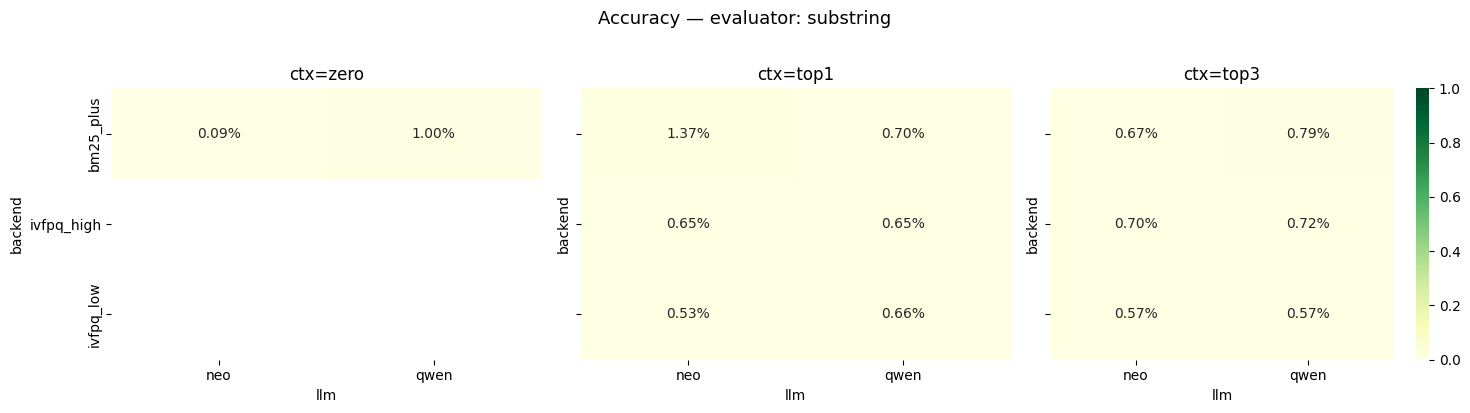

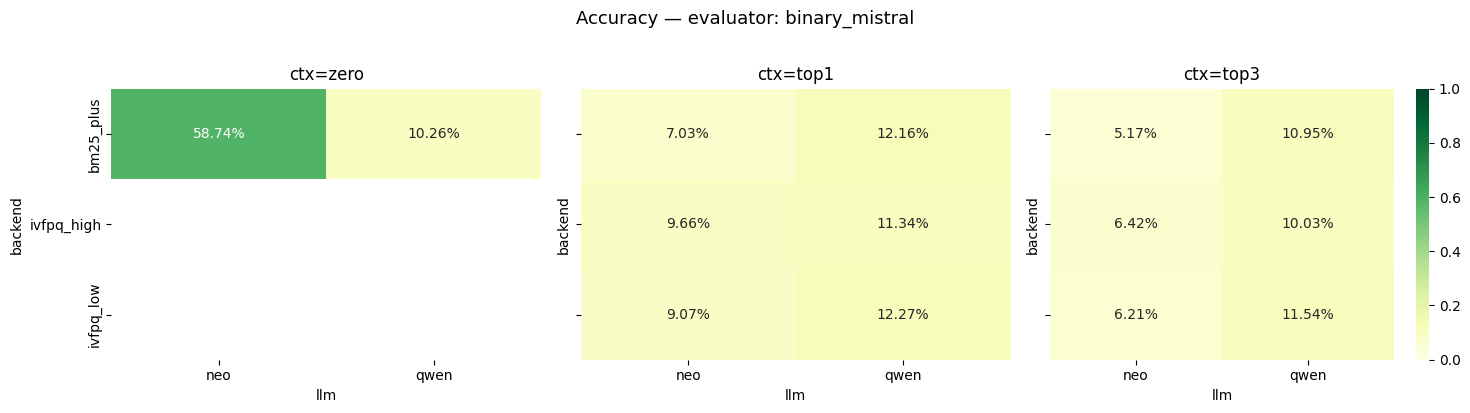

In [4]:
for ev in EVALUATOR_KEYS:
    fig, axes = plt.subplots(1, len(CTX_LABELS), figsize=(5 * len(CTX_LABELS), 4), sharey=True)
    if len(CTX_LABELS) == 1:
        axes = [axes]
    for ax, ctx in zip(axes, CTX_LABELS):
        try:
            piv = pivot_metric(evaluator=ev, ctx_label=ctx)
            sns.heatmap(piv, annot=True, fmt='.2%', cmap='YlGn', ax=ax,
                        vmin=0, vmax=1, cbar=(ctx == CTX_LABELS[-1]))
            ax.set_title(f'ctx={ctx}')
        except Exception as e:
            ax.set_title(f'ctx={ctx} — {e}')
    fig.suptitle(f'Accuracy — evaluator: {ev}', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / f'heatmap_accuracy_{ev}.png', bbox_inches='tight', dpi=150)
    plt.show()

## 4. Context size effect (retrieval backends only)

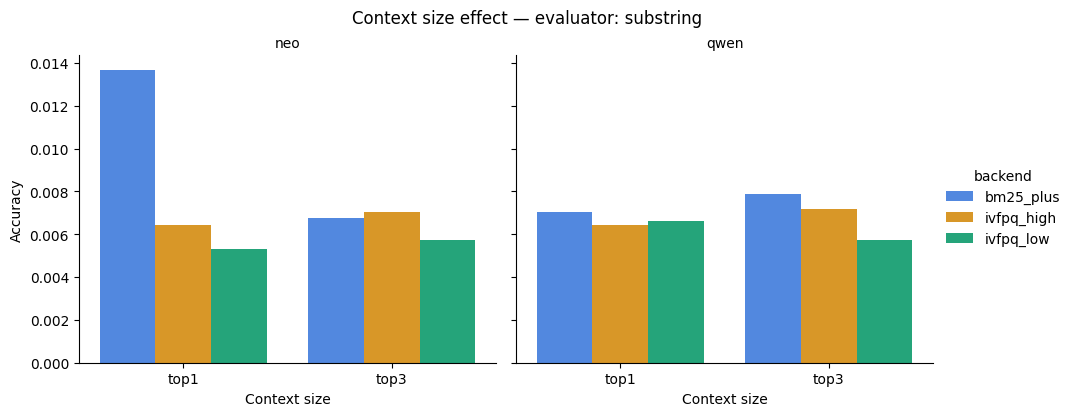

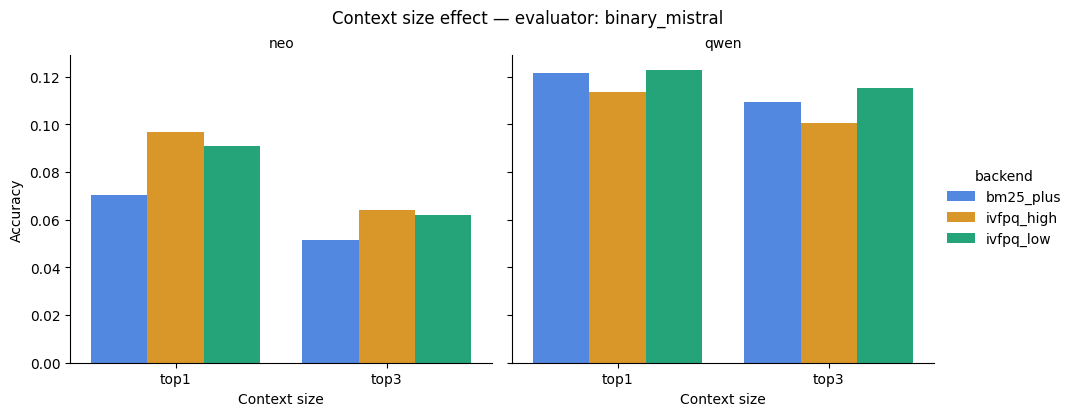

In [5]:
retrieval_backends = [b for b in BACKEND_KEYS if b != 'zero_shot']
ctx_options = [c for c in CTX_LABELS if c != 'zero']

for ev in EVALUATOR_KEYS:
    df_ctx = (
        results_all[
            (results_all['evaluator'] == ev) &
            (results_all['backend'].isin(retrieval_backends))
        ]
        .groupby(['llm', 'backend', 'ctx_label'])['evaluation_score']
        .mean()
        .reset_index()
        .rename(columns={'evaluation_score': 'accuracy'})
    )
    if df_ctx.empty:
        continue
    g = sns.catplot(
        data=df_ctx, x='ctx_label', y='accuracy', hue='backend',
        col='llm', kind='bar', height=4, aspect=1.2,
        palette=[backend_color(b) for b in df_ctx['backend'].unique()],
    )
    g.set_axis_labels('Context size', 'Accuracy')
    g.set_titles('{col_name}')
    g.figure.suptitle(f'Context size effect — evaluator: {ev}', y=1.03)
    plt.savefig(IMAGES_DIR / f'ctx_effect_{ev}.png', bbox_inches='tight', dpi=150)
    plt.show()